## Chapter 6 of *lme4: Mixed-effects modeling with R* (2022)

In [1]:
from hea.io import data
from hea.R import factor, anova
from hea.tidy import col
from hea.models import lme
from hea.family import Binomial

### 6.1

In [2]:
Contraception = (
    data("Contraception")
        .mutate(
            factor("woman"),
            factor("district"),
            factor("use"),
            factor("livch"),
            factor("urban"),
            ch = factor(col("livch") != "0", labels={False: "N", True: "Y"})
        )
)
Contraception.glimpse()

Rows: 1934
Columns: 7
$ woman    <enum> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ district <enum> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ use      <enum> N, N, N, N, N, N, N, N, N, N
$ livch    <enum> 3+, 0, 2, 3+, 0, 0, 3+, 3+, 1, 3+
$ age       <f64> 18.44, -5.5599, 1.44, 8.44, -13.559, -11.56, 18.44, -3.5599, -5.5599, 1.44
$ urban    <enum> Y, Y, Y, Y, Y, Y, Y, Y, Y, Y
$ ch       <enum> Y, N, Y, Y, N, N, Y, Y, Y, Y



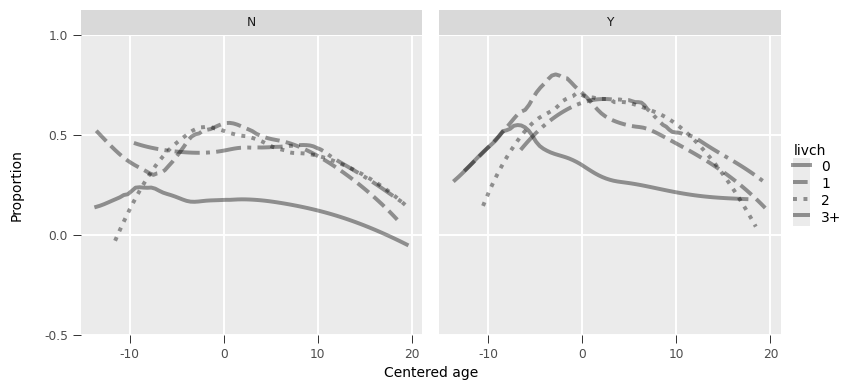

In [3]:
(
    Contraception
        .ggplot(x="age", y="use", linetype="livch")
        .geom_smooth(method="loess", se=False, color="black")
        .facet_wrap("~urban")
        .labs(x="Centered age", y="Proportion")
        .ylim(0, 1)
)

In [4]:
fm10 = lme("use ~ poly(age, 2) + urban + livch + (1 | district)", data=Contraception, family=Binomial())
fm10.summary()

Generalized linear mixed model fit by maximum likelihood (Laplace Approximation)
 Family: binomial  ( logit )
Formula: use ~ poly(age, 2) + urban + livch + (1 | district)

      AIC       BIC     logLik -2*log(L) df.resid
2388.7287 2433.2675 -1186.3644 2372.7287     1926

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.8438 -0.7592 -0.4640 0.9493 3.0715

Random effects:
 Groups   Name        Variance Std.Dev.
 district (Intercept) 0.2258   0.4752
Number of obs: 1934, groups:  district, 60

Fixed effects:
               Estimate  Std. Error  z value   Pr(>|z|)
(Intercept)     -1.4055      0.1521   -9.238  < 2.2e-16  ***
poly(age, 2)1   -5.7989      3.2861   -1.765    0.07762  .
poly(age, 2)2  -16.3209      2.6071   -6.260  3.846e-10  ***
urbanY           0.6973      0.1209    5.769  7.971e-09  ***
livch1           0.8150      0.1632    4.994  5.908e-07  ***
livch2           0.9165      0.1863    4.918  8.742e-07  ***
livch3+          0.9150      0.1873    4.885  1.034e-06  **

In [5]:
fm11 = lme("use ~ poly(age, 2) + urban + ch + (1 | district)", data=Contraception, family=Binomial())
fm11.summary()

Generalized linear mixed model fit by maximum likelihood (Laplace Approximation)
 Family: binomial  ( logit )
Formula: use ~ poly(age, 2) + urban + ch + (1 | district)

      AIC       BIC     logLik -2*log(L) df.resid
2385.1858 2418.5899 -1186.5929 2373.1858     1928

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.8151 -0.7620 -0.4619 0.9518 3.1034

Random effects:
 Groups   Name        Variance Std.Dev.
 district (Intercept) 0.2247   0.474
Number of obs: 1934, groups:  district, 60

Fixed effects:
               Estimate  Std. Error  z value   Pr(>|z|)
(Intercept)     -1.3827      0.1466   -9.435  < 2.2e-16  ***
poly(age, 2)1   -4.8349      2.7346   -1.768    0.07705  .
poly(age, 2)2  -16.5821      2.5773   -6.434  1.243e-10  ***
urbanY           0.6929      0.1207    5.743  9.301e-09  ***
chY              0.8604      0.1483    5.800  6.614e-09  ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
                     (Intr

In [6]:
anova(fm11, fm10)

Analysis of Variance Table (likelihood ratio test)

fm11: use ~ poly(age, 2) + urban + ch + (1 | district)
fm10: use ~ poly(age, 2) + urban + livch + (1 | district)

      npar        AIC        BIC      logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
fm11     6  2385.1858  2418.5899  -1186.5929  2373.1858
fm10     8  2388.7287  2433.2675  -1186.3644  2372.7287  0.4571   2      0.7957
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


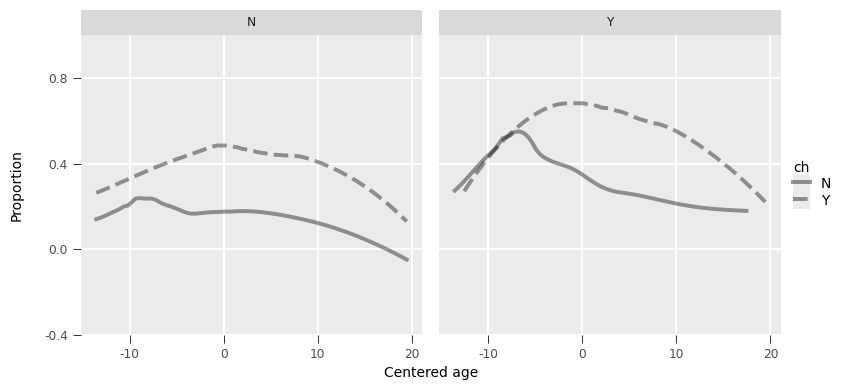

In [7]:
(
    Contraception
        .ggplot(x="age", y="use", linetype="ch")
        .geom_smooth(method="loess", se=False, color="black")
        .facet_wrap("~urban")
        .labs(x="Centered age", y="Proportion")
        .ylim(0, 1)
)

In [8]:
fm12 = lme("use ~ poly(age, 2) + ch + age:ch + urban + (1 | district)", data=Contraception, family=Binomial())
fm12.summary()

fixed-effect model matrix is rank deficient so dropping 1 column / coefficient


Generalized linear mixed model fit by maximum likelihood (Laplace Approximation)
 Family: binomial  ( logit )
Formula: use ~ poly(age, 2) + ch + age:ch + urban + (1 | district)

      AIC       BIC     logLik -2*log(L) df.resid
2379.1813 2418.1527 -1182.5907 2365.1813     1927

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.8721 -0.7560 -0.4668 0.9486 2.9974

Random effects:
 Groups   Name        Variance Std.Dev.
 district (Intercept) 0.223    0.4723
Number of obs: 1934, groups:  district, 60

Fixed effects:
                Estimate  Std. Error  z value   Pr(>|z|)
(Intercept)     -1.79066     0.21980  -8.1469  4.441e-16  ***
poly(age, 2)1   -0.73839     3.13173  -0.2358   0.813606
poly(age, 2)2  -20.59538     3.00984  -6.8427  7.773e-12  ***
chY              1.21073     0.20734   5.8393  5.243e-09  ***
urbanY           0.71401     0.12126   5.8882  3.903e-09  ***
age:chN         -0.06835     0.02545  -2.6854   0.007245  **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.

In [9]:
anova(fm11, fm12)

Analysis of Variance Table (likelihood ratio test)

fm11: use ~ poly(age, 2) + urban + ch + (1 | district)
fm12: use ~ poly(age, 2) + ch + age:ch + urban + (1 | district)

      npar        AIC        BIC      logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
fm11     6  2385.1858  2418.5899  -1186.5929  2373.1858
fm12     7  2379.1813  2418.1527  -1182.5907  2365.1813  8.0045   1    0.004666  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [10]:
fm13 = lme("use ~ poly(age, 2) + ch + age:ch + urban + (1 | urban:district)", data=Contraception, family=Binomial())
fm13.summary()

fixed-effect model matrix is rank deficient so dropping 1 column / coefficient


Generalized linear mixed model fit by maximum likelihood (Laplace Approximation)
 Family: binomial  ( logit )
Formula: use ~ poly(age, 2) + ch + age:ch + urban + (1 | urban:district)

      AIC       BIC     logLik -2*log(L) df.resid
2368.4750 2407.4464 -1177.2375 2354.4750     1927

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.9834 -0.7358 -0.4518 0.9090 2.9502

Random effects:
 Groups         Name        Variance Std.Dev.
 urban:district (Intercept) 0.3229   0.5682
Number of obs: 1934, groups:  urban:district, 102

Fixed effects:
                Estimate  Std. Error  z value   Pr(>|z|)
(Intercept)     -1.79746     0.22616  -7.9479  1.998e-15  ***
poly(age, 2)1   -0.82929     3.16929  -0.2617   0.793581
poly(age, 2)2  -20.12597     3.04137  -6.6174  3.655e-11  ***
chY              1.21285     0.20958   5.7871  7.161e-09  ***
urbanY           0.78667     0.17214   4.5699  4.880e-06  ***
age:chN         -0.06647     0.02566  -2.5902   0.009593  **
---
Signif. codes:  0 '**

In [11]:
anova(fm12, fm13)

Analysis of Variance Table (likelihood ratio test)

fm12: use ~ poly(age, 2) + ch + age:ch + urban + (1 | district)
fm13: use ~ poly(age, 2) + ch + age:ch + urban + (1 | urban:district)

      npar        AIC        BIC      logLik  -2*log(L)    Chisq  Df  Pr(>Chisq)
fm12     7  2379.1813  2418.1527  -1182.5907  2365.1813
fm13     7  2368.4750  2407.4464  -1177.2375  2354.4750  10.7063   0         NaN
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
